<a href="https://colab.research.google.com/github/Jenoprabakar/DeepLearning-lab-experiments/blob/main/dl7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [ ]:
def plot_confusion(model, name):

    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)

    plt.figure(figsize=(6,6))
    disp.plot()
    plt.title("Confusion Matrix - " + name)
    plt.show()

In [ ]:
def baseline_model():

    model = models.Sequential()

    model.add(layers.Conv2D(32,(3,3),activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,activation='relu'))

    model.add(layers.Dense(10,activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8011 - loss: 0.5689 - val_accuracy: 0.8811 - val_loss: 0.3302
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8972 - loss: 0.2839 - val_accuracy: 0.8873 - val_loss: 0.3107
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9161 - loss: 0.2325 - val_accuracy: 0.9086 - val_loss: 0.2545
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9267 - loss: 0.2004 - val_accuracy: 0.9147 - val_loss: 0.2403
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9360 - loss: 0.1708 - val_accuracy: 0.9142 - val_loss: 0.2453
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9096 - loss: 0.2665
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

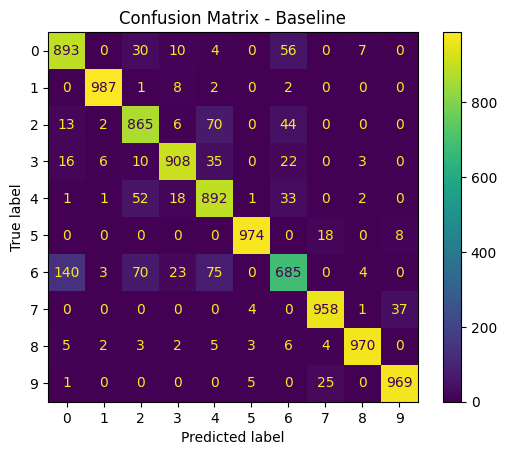

In [ ]:
baseline = baseline_model()

baseline.fit(X_train,y_train,
             epochs=5,
             validation_split=0.2)

baseline.evaluate(X_test,y_test)

plot_confusion(baseline,"Baseline")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8019 - loss: 0.5658 - val_accuracy: 0.8707 - val_loss: 0.3531
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8995 - loss: 0.2787 - val_accuracy: 0.9045 - val_loss: 0.2647
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9152 - loss: 0.2340 - val_accuracy: 0.9031 - val_loss: 0.2687
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9272 - loss: 0.1933 - val_accuracy: 0.9078 - val_loss: 0.2510
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9376 - loss: 0.1684 - val_accuracy: 0.9080 - val_loss: 0.2522
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 600x600 with 0 Axes>

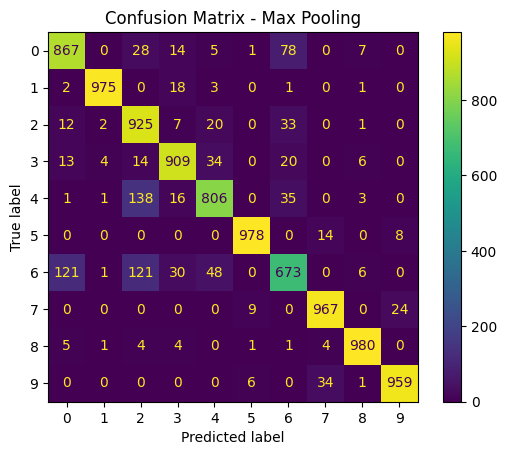

In [ ]:
def max_pool_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,activation='relu'))

    model.add(layers.Dense(10,activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


max_model=max_pool_model()

max_model.fit(X_train,y_train,
              epochs=5,
              validation_split=0.2)

plot_confusion(max_model,"Max Pooling")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7898 - loss: 0.5954 - val_accuracy: 0.8786 - val_loss: 0.3408
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8877 - loss: 0.3083 - val_accuracy: 0.8966 - val_loss: 0.2824
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9056 - loss: 0.2581 - val_accuracy: 0.8981 - val_loss: 0.2737
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9164 - loss: 0.2272 - val_accuracy: 0.9010 - val_loss: 0.2741
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9280 - loss: 0.1972 - val_accuracy: 0.9078 - val_loss: 0.2502
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

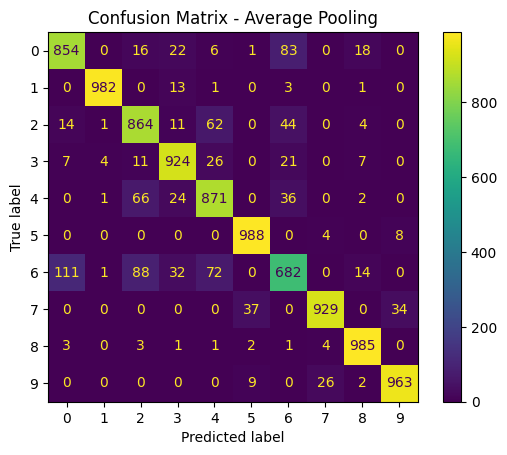

In [ ]:
def avg_pool_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.AveragePooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,activation='relu'))

    model.add(layers.Dense(10,activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


avg_model=avg_pool_model()

avg_model.fit(X_train,y_train,
              epochs=5,
              validation_split=0.2)

plot_confusion(avg_model,"Average Pooling")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7651 - loss: 0.6520 - val_accuracy: 0.8689 - val_loss: 0.3742
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8822 - loss: 0.3344 - val_accuracy: 0.8867 - val_loss: 0.3236
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8940 - loss: 0.2950 - val_accuracy: 0.8940 - val_loss: 0.3017
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9043 - loss: 0.2703 - val_accuracy: 0.8928 - val_loss: 0.3050
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9114 - loss: 0.2504 - val_accuracy: 0.8986 - val_loss: 0.2900
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9177 - loss: 0.2316 - val_accuracy: 0.9024 - val_loss: 0.2810
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9244 - loss: 0.2141 - val_accuracy: 0.9007 - val_loss: 0.2785
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9265 - loss: 0.2062 - 

<Figure size 600x600 with 0 Axes>

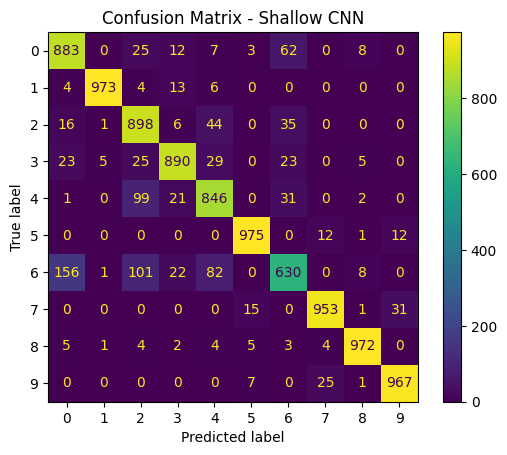

In [ ]:
def shallow_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


shallow=shallow_model()

shallow.fit(X_train,y_train,
            epochs=10,
            validation_split=0.2)

plot_confusion(shallow,"Shallow CNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7661 - loss: 0.6471 - val_accuracy: 0.8712 - val_loss: 0.3593
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8813 - loss: 0.3237 - val_accuracy: 0.8948 - val_loss: 0.2856
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9031 - loss: 0.2670 - val_accuracy: 0.8942 - val_loss: 0.2840
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9121 - loss: 0.2347 - val_accuracy: 0.9028 - val_loss: 0.2666
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9260 - loss: 0.2009 - val_accuracy: 0.9078 - val_loss: 0.2612
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 600x600 with 0 Axes>

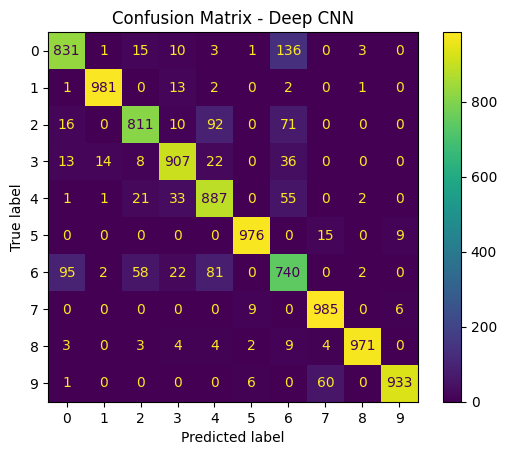

In [ ]:
def deep_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,(3,3),
                            activation='relu'))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


deep=deep_model()

deep.fit(X_train,y_train,
         epochs=5,
         validation_split=0.2)

plot_confusion(deep,"Deep CNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8063 - loss: 0.5432 - val_accuracy: 0.8911 - val_loss: 0.3008
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9014 - loss: 0.2751 - val_accuracy: 0.9017 - val_loss: 0.2751
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9190 - loss: 0.2224 - val_accuracy: 0.9039 - val_loss: 0.2679
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9296 - loss: 0.1906 - val_accuracy: 0.9032 - val_loss: 0.2756
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9417 - loss: 0.1572 - val_accuracy: 0.9098 - val_loss: 0.2545
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

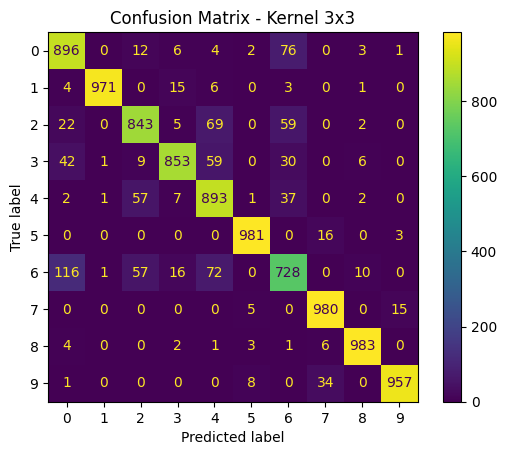

In [ ]:
def kernel3():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


k3=kernel3()

k3.fit(X_train,y_train,
       epochs=5,
       validation_split=0.2)

plot_confusion(k3,"Kernel 3x3")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8015 - loss: 0.5668 - val_accuracy: 0.8827 - val_loss: 0.3303
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8937 - loss: 0.2933 - val_accuracy: 0.8939 - val_loss: 0.2887
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9128 - loss: 0.2388 - val_accuracy: 0.8983 - val_loss: 0.2809
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9232 - loss: 0.2078 - val_accuracy: 0.9079 - val_loss: 0.2527
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9340 - loss: 0.1770 - val_accuracy: 0.9065 - val_loss: 0.2601
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 600x600 with 0 Axes>

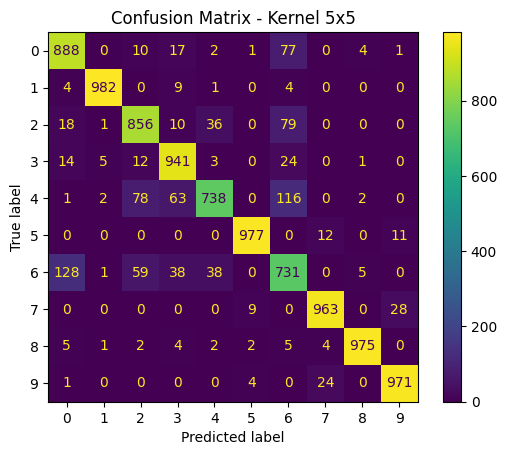

In [ ]:
def kernel5():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(5,5),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


k5=kernel5()

k5.fit(X_train,y_train,
       epochs=5,
       validation_split=0.2)

plot_confusion(k5,"Kernel 5x5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8102 - loss: 0.5430 - val_accuracy: 0.8731 - val_loss: 0.3414
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8946 - loss: 0.2877 - val_accuracy: 0.9007 - val_loss: 0.2762
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9143 - loss: 0.2315 - val_accuracy: 0.9009 - val_loss: 0.2669
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9295 - loss: 0.1938 - val_accuracy: 0.9072 - val_loss: 0.2560
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9416 - loss: 0.1609 - val_accuracy: 0.9089 - val_loss: 0.2514
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

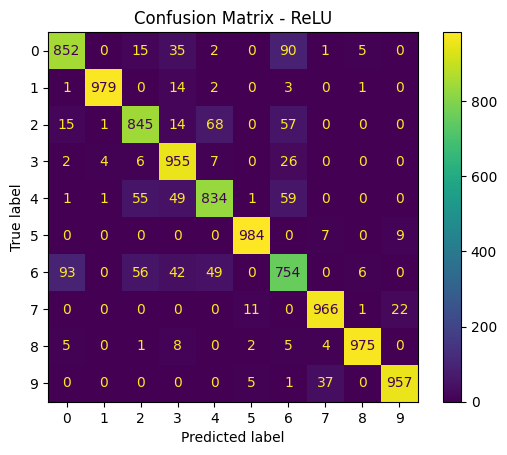

In [ ]:
def relu_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


relu=relu_model()

relu.fit(X_train,y_train,
         epochs=5,
         validation_split=0.2)

plot_confusion(relu,"ReLU")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1021 - loss: 2.3424 - val_accuracy: 0.0983 - val_loss: 2.3090
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0976 - loss: 2.3107 - val_accuracy: 0.0983 - val_loss: 2.3093
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1017 - loss: 2.3096 - val_accuracy: 0.1027 - val_loss: 2.3168
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1008 - loss: 2.3122 - val_accuracy: 0.1929 - val_loss: 2.2989
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2899 - loss: 1.9982 - val_accuracy: 0.6667 - val_loss: 0.9408
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

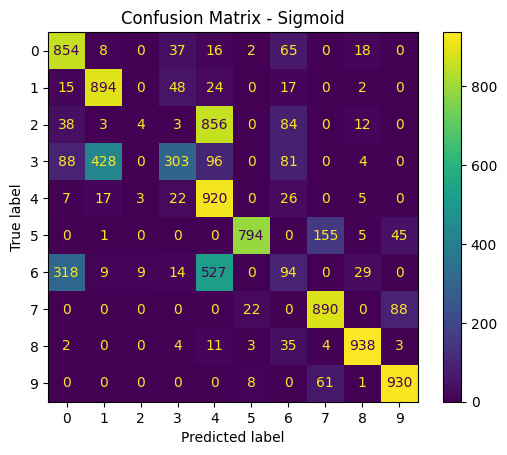

In [ ]:
def sigmoid_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='sigmoid',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='sigmoid'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


sig=sigmoid_model()

sig.fit(X_train,y_train,
        epochs=5,
        validation_split=0.2)

plot_confusion(sig,"Sigmoid")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7993 - loss: 0.5681 - val_accuracy: 0.8782 - val_loss: 0.3415
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8970 - loss: 0.2890 - val_accuracy: 0.9033 - val_loss: 0.2674
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9142 - loss: 0.2348 - val_accuracy: 0.9025 - val_loss: 0.2740
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9253 - loss: 0.2029 - val_accuracy: 0.9101 - val_loss: 0.2492
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9401 - loss: 0.1660 - val_accuracy: 0.9105 - val_loss: 0.2557
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

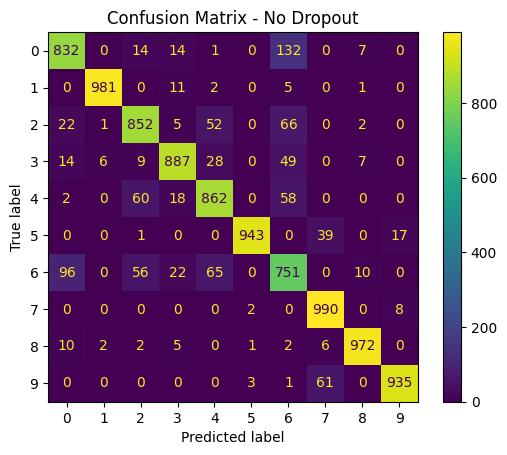

In [ ]:
def no_dropout():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


nodrop=no_dropout()

nodrop.fit(X_train,y_train,
           epochs=5,
           validation_split=0.2)

plot_confusion(nodrop,"No Dropout")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7458 - loss: 0.7247 - val_accuracy: 0.8832 - val_loss: 0.3304
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8667 - loss: 0.3798 - val_accuracy: 0.8932 - val_loss: 0.2887
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8853 - loss: 0.3265 - val_accuracy: 0.8978 - val_loss: 0.2787
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8920 - loss: 0.2953 - val_accuracy: 0.9010 - val_loss: 0.2710
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2691 - val_accuracy: 0.9078 - val_loss: 0.2499
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x600 with 0 Axes>

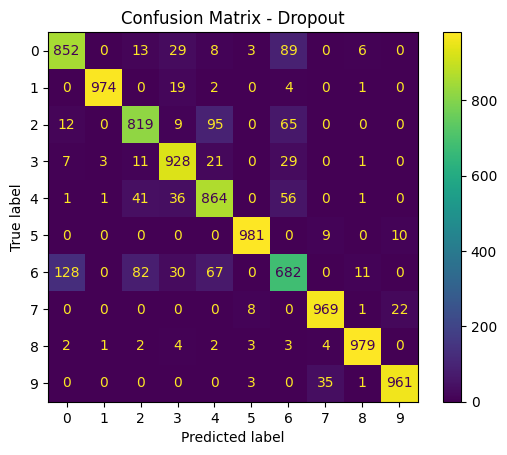

In [ ]:
def dropout_model():

    model=models.Sequential()

    model.add(layers.Conv2D(32,(3,3),
                            activation='relu',
                            input_shape=(28,28,1)))

    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128,
                           activation='relu'))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10,
                           activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


drop=dropout_model()

drop.fit(X_train,y_train,
         epochs=5,
         validation_split=0.2)

plot_confusion(drop,"Dropout")

In [ ]:
models_list = [baseline,max_model,avg_model,
               shallow,deep,k3,k5,
               relu,sig,nodrop,drop]

names = ["Baseline","MaxPool","AvgPool",
         "Shallow","Deep",
         "Kernel3","Kernel5",
         "ReLU","Sigmoid",
         "NoDrop","Dropout"]

for m,n in zip(models_list,names):

    loss,acc = m.evaluate(X_test,y_test,verbose=0)

    print(n,"Accuracy =",acc)

Baseline Accuracy = 0.910099983215332
MaxPool Accuracy = 0.9039000272750854
AvgPool Accuracy = 0.90420001745224
Shallow Accuracy = 0.8986999988555908
Deep Accuracy = 0.9021999835968018
Kernel3 Accuracy = 0.9085000157356262
Kernel5 Accuracy = 0.9021999835968018
ReLU Accuracy = 0.910099983215332
Sigmoid Accuracy = 0.6621000170707703
NoDrop Accuracy = 0.9004999995231628
Dropout Accuracy = 0.9009000062942505



===== Test CNN Models with Input Image =====
Enter test image index (0-9999): 100


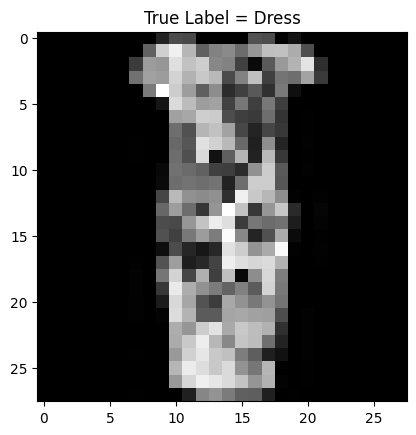


Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Baseline -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MaxPool -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
AvgPool -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Shallow -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Deep -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Kernel3 -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Kernel5 -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
ReLU -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Sigmoid -> Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
NoDrop -> Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Dropout -> Dress


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle Boot']


print("\n===== Test CNN Models with Input Image =====")

img_index = int(input("Enter test image index (0-9999): "))

# Select image
test_img = X_test[img_index]
true_label = y_test[img_index]

plt.imshow(test_img.reshape(28,28), cmap='gray')
plt.title("True Label = " + class_names[true_label])
plt.show()

# Models to test
models_list = [baseline,max_model,avg_model,
               shallow,deep,k3,k5,
               relu,sig,nodrop,drop]

names = ["Baseline","MaxPool","AvgPool",
         "Shallow","Deep",
         "Kernel3","Kernel5",
         "ReLU","Sigmoid",
         "NoDrop","Dropout"]


print("\nPredictions:\n")

for m,n in zip(models_list,names):

    pred = m.predict(test_img.reshape(1,28,28,1))
    pred_class = np.argmax(pred)

    print(n,"->",class_names[pred_class])